# Problem 1 — Fourier Approximation of $f(x) = x - 1$ on $[-1,\,1]$

**Given:** $f(x) = x - 1$ on $[-1, 1]$, so $L = 1$.

**Recall** the Fourier series representation:

$$f(x) \sim a_0 + \sum_{n=1}^{N} \left[ a_n \cos\!\left(\frac{n\pi x}{L}\right) + b_n \sin\!\left(\frac{n\pi x}{L}\right) \right]$$

with coefficients:

$$a_0 = \frac{1}{2L}\int_{-L}^{L} f(x)\,dx, \qquad a_n = \frac{1}{L}\int_{-L}^{L} f(x)\cos\!\left(\frac{n\pi x}{L}\right)dx, \qquad b_n = \frac{1}{L}\int_{-L}^{L} f(x)\sin\!\left(\frac{n\pi x}{L}\right)dx$$

In [1]:
import numpy as np
from scipy import integrate
import sympy as sp
import matplotlib.pyplot as plt

## Part (a) — Find the first four terms ($n = 0, 1, 2, 3$)

We compute each Fourier coefficient by hand with $f(x) = x - 1$ and $L = 1$.

---

### Step 1: Compute $a_0$

$$a_0 = \frac{1}{2L}\int_{-L}^{L} f(x)\,dx = \frac{1}{2}\int_{-1}^{1}(x-1)\,dx = \frac{1}{2}\left[\frac{x^2}{2} - x\right]_{-1}^{1}$$

$$= \frac{1}{2}\left[\left(\frac{1}{2} - 1\right) - \left(\frac{1}{2} + 1\right)\right] = \frac{1}{2}\left[-\frac{1}{2} - \frac{3}{2}\right] = \frac{1}{2}(-2)$$

$$\boxed{a_0 = -1}$$

---

### Step 2: Compute $a_n$ for $n \ge 1$

$$a_n = \frac{1}{L}\int_{-L}^{L}f(x)\cos\!\left(\frac{n\pi x}{L}\right)dx = \int_{-1}^{1}(x-1)\cos(n\pi x)\,dx = \underbrace{\int_{-1}^{1} x\cos(n\pi x)\,dx}_{I_1} - \underbrace{\int_{-1}^{1}\cos(n\pi x)\,dx}_{I_2}$$

**$I_1$:** The integrand $x\cos(n\pi x)$ is **odd** ($x$ is odd, $\cos(n\pi x)$ is even, so their product is odd). On a symmetric interval:

$$I_1 = 0$$

**$I_2$:** Direct evaluation:

$$I_2 = \left[\frac{\sin(n\pi x)}{n\pi}\right]_{-1}^{1} = \frac{\sin(n\pi) - \sin(-n\pi)}{n\pi} = \frac{0 - 0}{n\pi} = 0$$

since $\sin(n\pi) = 0$ for all $n \in \mathbb{Z}$.

$$\boxed{a_n = 0 \quad \text{for all } n \ge 1}$$

---

### Step 3: Compute $b_n$ for $n \ge 1$

$$b_n = \frac{1}{L}\int_{-L}^{L}f(x)\sin\!\left(\frac{n\pi x}{L}\right)dx = \int_{-1}^{1}(x - 1)\sin(n\pi x)\,dx = \underbrace{\int_{-1}^{1} x\sin(n\pi x)\,dx}_{J_1} - \underbrace{\int_{-1}^{1}\sin(n\pi x)\,dx}_{J_2}$$

**$J_2$:** The integrand $\sin(n\pi x)$ is **odd**, so on $[-1,1]$:

$$J_2 = 0$$

**$J_1$:** The integrand $x\sin(n\pi x)$ is **even** (odd $\times$ odd $=$ even), so:

$$J_1 = 2\int_{0}^{1} x\sin(n\pi x)\,dx$$

**Integration by parts** with $u = x$, $dv = \sin(n\pi x)\,dx$, giving $du = dx$, $v = -\dfrac{\cos(n\pi x)}{n\pi}$:

$$\int_0^1 x\sin(n\pi x)\,dx = \left[-\frac{x\cos(n\pi x)}{n\pi}\right]_0^1 + \int_0^1 \frac{\cos(n\pi x)}{n\pi}\,dx$$

$$= -\frac{\cos(n\pi)}{n\pi} + \left[\frac{\sin(n\pi x)}{n^2\pi^2}\right]_0^1 = -\frac{\cos(n\pi)}{n\pi} + \frac{\sin(n\pi)}{n^2\pi^2}$$

Using $\sin(n\pi) = 0$ and $\cos(n\pi) = (-1)^n$:

$$J_1 = 2\left[-\frac{(-1)^n}{n\pi}\right] = \frac{-2(-1)^n}{n\pi}$$

Therefore:

$$\boxed{b_n = \frac{-2(-1)^n}{n\pi}}$$

---

### Step 4: Evaluate for $n = 0, 1, 2, 3$

| $n$ | $a_n$ | $b_n$ | Exact value | Decimal |
|:---:|:------:|:-----:|:----------:|:-------:|
| $0$ | $-1$   | —     | —          | —       |
| $1$ | $0$    | $\dfrac{-2(-1)^1}{1\cdot\pi}$ | $\dfrac{2}{\pi}$   | $\approx 0.63662$ |
| $2$ | $0$    | $\dfrac{-2(-1)^2}{2\pi}$ | $-\dfrac{1}{\pi}$  | $\approx -0.31831$ |
| $3$ | $0$    | $\dfrac{-2(-1)^3}{3\pi}$ | $\dfrac{2}{3\pi}$  | $\approx 0.21221$ |

---

### Answer (a)

The four-term Fourier approximation ($n = 0, 1, 2, 3$) is:

$$\boxed{f(x) \approx -1 + \frac{2}{\pi}\sin(\pi x) - \frac{1}{\pi}\sin(2\pi x) + \frac{2}{3\pi}\sin(3\pi x)}$$

In [2]:
# Part (a) — Verification using SymPy
x = sp.Symbol('x')
L = 1
f_sym = x - 1

a0_sym = sp.Rational(1, 2*L) * sp.integrate(f_sym, (x, -L, L))

print("Verification of Part (a) coefficients:")
print(f"  a_0 = {a0_sym}")
for n_val in range(1, 4):
    a_n = sp.Rational(1, L) * sp.integrate(f_sym * sp.cos(n_val * sp.pi * x / L), (x, -L, L))
    b_n = sp.Rational(1, L) * sp.integrate(f_sym * sp.sin(n_val * sp.pi * x / L), (x, -L, L))
    print(f"  a_{n_val} = {sp.simplify(a_n)},  b_{n_val} = {sp.simplify(b_n)} = {float(b_n):.10f}")

Verification of Part (a) coefficients:
  a_0 = -1
  a_1 = 0,  b_1 = 2/pi = 0.6366197724
  a_2 = 0,  b_2 = -1/pi = -0.3183098862
  a_3 = 0,  b_3 = 2/(3*pi) = 0.2122065908


## Part (b) — Find the first fifty-one terms ($n = 0, 1, \ldots, 50$)

From the derivation in Part (a), the closed-form expressions for **all** coefficients are:

$$a_0 = -1, \qquad a_n = 0 \;\;\text{for } n \ge 1, \qquad b_n = \frac{-2(-1)^n}{n\pi} \;\;\text{for } n \ge 1$$

These hold for every $n$, so no additional integration is needed — we just evaluate the formula. The sign alternates:

$$b_n = \begin{cases} +\dfrac{2}{n\pi} & \text{if } n \text{ is odd} \\[6pt] -\dfrac{2}{n\pi} & \text{if } n \text{ is even} \end{cases}$$

---

### Answer (b)

The 50-term Fourier approximation is:

$$\boxed{f(x) \approx -1 + \sum_{n=1}^{50} \frac{-2(-1)^n}{n\pi}\sin(n\pi x)}$$

Expanded:

$$f(x) \approx -1 + \frac{2}{\pi}\sin(\pi x) - \frac{1}{\pi}\sin(2\pi x) + \frac{2}{3\pi}\sin(3\pi x) - \frac{1}{2\pi}\sin(4\pi x) + \cdots + \frac{1}{25\pi}\sin(50\pi x)$$

The complete table of all 51 coefficients is computed and listed below.

In [3]:
# Part (b) — Compute and verify all 51 Fourier coefficients
f = lambda x: x - 1
L = 1
N = 50

# Numerical computation via quadrature
a0_num, _ = integrate.quad(f, -L, L)
a0_num /= (2 * L)

a = np.zeros(N + 1)
b = np.zeros(N + 1)
a[0] = a0_num

for n in range(1, N + 1):
    a[n], _ = integrate.quad(lambda x, n=n: f(x) * np.cos(n * np.pi * x / L), -L, L)
    a[n] /= L
    b[n], _ = integrate.quad(lambda x, n=n: f(x) * np.sin(n * np.pi * x / L), -L, L)
    b[n] /= L

# Display table with exact closed-form comparison
print("Complete table of Fourier coefficients for f(x) = x − 1, L = 1")
print(f"{'n':>4s}  {'a_n (numerical)':>18s}  {'b_n (numerical)':>18s}  {'b_n (exact)':>18s}")
print("─" * 64)
print(f"{'0':>4s}  {a[0]:>18.12f}  {'—':>18s}  {'−1':>18s}")
for n in range(1, N + 1):
    exact_bn = -2 * (-1)**n / (n * np.pi)
    print(f"{n:>4d}  {a[n]:>18.12f}  {b[n]:>18.12f}  {exact_bn:>18.12f}")

Complete table of Fourier coefficients for f(x) = x − 1, L = 1
   n     a_n (numerical)     b_n (numerical)         b_n (exact)
────────────────────────────────────────────────────────────────
   0     -1.000000000000                   —                  −1
   1     -0.000000000000      0.636619772368      0.636619772368
   2      0.000000000000     -0.318309886184     -0.318309886184
   3     -0.000000000000      0.212206590789      0.212206590789
   4     -0.000000000000     -0.159154943092     -0.159154943092
   5      0.000000000000      0.127323954474      0.127323954474
   6      0.000000000000     -0.106103295395     -0.106103295395
   7     -0.000000000000      0.090945681767      0.090945681767
   8      0.000000000000     -0.079577471546     -0.079577471546
   9     -0.000000000000      0.070735530263      0.070735530263
  10      0.000000000000     -0.063661977237     -0.063661977237
  11     -0.000000000000      0.057874524761      0.057874524761
  12      0.000000000000   

## Part (c) — Plot $f(x)$ and the Fourier approximation on $[-1,\,1]$ and $[-3,\,3]$

We plot $f(x) = x - 1$ together with the $N = 50$ term Fourier series on both intervals. On $[-3,3]$ the periodic extension of the Fourier series is visible (period $2L = 2$).

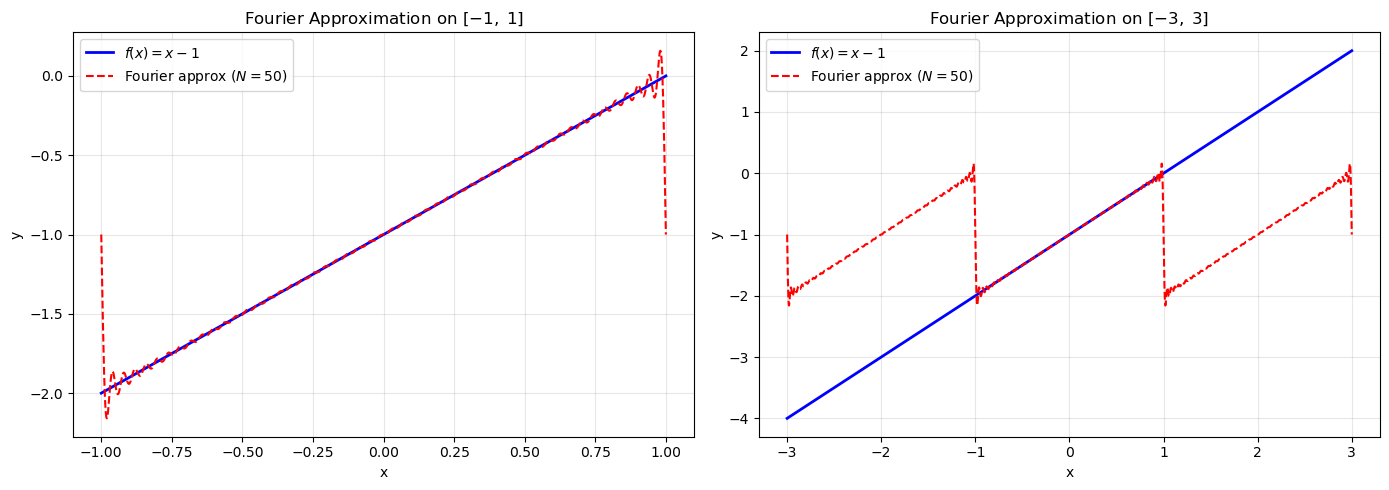

In [4]:
# Part (c): Plot f(x) and the Fourier approximation

def fourier_approx(x, a, b, L, N):
    """Evaluate the N-term Fourier approximation at points x."""
    result = a[0] * np.ones_like(x)
    for n in range(1, N + 1):
        result += a[n] * np.cos(n * np.pi * x / L) + b[n] * np.sin(n * np.pi * x / L)
    return result

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot on [-1, 1] ---
x1 = np.linspace(-1, 1, 1000)
axes[0].plot(x1, f(x1), 'b-', linewidth=2, label=r'$f(x) = x - 1$')
axes[0].plot(x1, fourier_approx(x1, a, b, L, N), 'r--', linewidth=1.5,
             label=f'Fourier approx ($N={N}$)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(r'Fourier Approximation on $[-1,\;1]$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot on [-3, 3] ---
x2 = np.linspace(-3, 3, 3000)
axes[1].plot(x2, f(x2), 'b-', linewidth=2, label=r'$f(x) = x - 1$')
axes[1].plot(x2, fourier_approx(x2, a, b, L, N), 'r--', linewidth=1.5,
             label=f'Fourier approx ($N={N}$)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'Fourier Approximation on $[-3,\;3]$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()